In [ ]:
# Install mlflow if not already present
import subprocess
subprocess.run(["pip", "install", "mlflow"], check=True)


# ✈️ DelayPredict — 02 Baseline Model

**Goal:** Establish a performance baseline for binary flight delay classification.

We train two models in this notebook:
1. **DummyClassifier** — always predicts the majority class. Sets the absolute floor any real model must beat.
2. **Logistic Regression** — simple, interpretable linear model. Our actual baseline.

Results and the trained model are saved for comparison in `03_model_comparison.ipynb`.

---
**Input:** `data/processed/airlines_delay_eda.csv` (output of `01_eda.ipynb`)  
**Output:** `models/baseline_model.pkl`, `data/processed/baseline_metrics.csv`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

import joblib
import mlflow
import mlflow.sklearn

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42  # fixed seed for reproducibility


## 2. Load Dataset

We prefer the processed CSV from `01_eda.ipynb` (already cleaned and feature-engineered).  
If it does not exist, we fall back to the raw file and recreate `DepartureHour` on the fly.

In [2]:
PROCESSED_PATH = Path("../data/processed/airlines_delay_eda.csv")
RAW_PATH       = Path("../data/raw/airlines_delay.csv")

if PROCESSED_PATH.exists():
    DATA_PATH = PROCESSED_PATH
elif RAW_PATH.exists():
    DATA_PATH = RAW_PATH
else:
    raise FileNotFoundError(
        f"Dataset not found. Place airlines_delay.csv in {RAW_PATH.parent}"
    )

df = pd.read_csv(DATA_PATH)

# ── Fallback feature engineering (only runs if raw data is loaded) ──────────
# Time is stored as minutes since midnight (0 = 00:00, 1439 = 23:59)
if "DepartureHour" not in df.columns and "Time" in df.columns:
    df["DepartureHour"] = df["Time"] // 60

# ── Drop columns that must not enter the model ───────────────────────────────
# id, Flight  : identifiers, no predictive value
# Time        : replaced by DepartureHour
# DepartureMinute : no signal found in EDA
# IsWeekend   : redundant with DayOfWeek
# LengthBin, Route : EDA exploration columns, not model features
drop_cols = ["id", "Flight", "Time", "DepartureMinute", "IsWeekend", "LengthBin", "Route"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print("Source :", DATA_PATH)
print("Shape  :", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())


Source : ..\data\processed\airlines_delay_eda.csv
Shape  : (539383, 7)
Columns: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'DepartureHour', 'Delay']


,Airline,AirportFrom,AirportTo,DayOfWeek,Length,DepartureHour,Delay
0,CO,SFO,IAH,3,205,0,1
1,US,PHX,CLT,3,222,0,1
2,AA,LAX,DFW,3,165,0,1
3,AA,SFO,DFW,3,195,0,1
4,AS,ANC,SEA,3,202,0,0


## 3. Features and Target

**Target:** `Delay` — 1 if the flight arrived more than 15 minutes late, 0 otherwise.

The class distribution is mildly imbalanced (~55 / 45).  
The majority-class accuracy (~55%) is the minimum any model must exceed to be useful.

In [3]:
TARGET = "Delay"

X = df.drop(columns=[TARGET])   # feature matrix
y = df[TARGET]                   # target vector (0 = no delay, 1 = delay)

print("Features:", X.columns.tolist())
print("X shape :", X.shape)
print()

# Class distribution — the majority class accuracy is the floor to beat
dist = y.value_counts(normalize=True).mul(100).round(1).rename("% share")
print("Target distribution:")
display(dist)

majority_acc = dist.max() / 100
print(f"\nMajority class accuracy (floor to beat): {majority_acc:.2%}")


Features: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'DepartureHour']
X shape : (539383, 6)

Target distribution:


Delay
0    55.5
1    44.5
Name: % share, dtype: float64


Majority class accuracy (floor to beat): 55.50%


## 4. Feature Types

| Feature | Type | Preprocessing | Reason |
|---|---|---|---|
| Airline | Categorical | OneHotEncoder | 18 carriers |
| AirportFrom | Categorical | OneHotEncoder | 293 airports |
| AirportTo | Categorical | OneHotEncoder | 293 airports |
| DayOfWeek | Categorical | OneHotEncoder | No linear order for delay risk |
| Length | Numeric | StandardScaler | Flight duration in minutes |
| DepartureHour | Numeric | StandardScaler | Hour of departure (0–23) |

> **Note:** OHE on the two airport columns alone produces ~586 binary columns.  
> This is expected and manageable for Logistic Regression.

In [4]:
# Categorical features → OneHotEncoding
# DayOfWeek treated as categorical: no meaningful linear relationship with delay
CATEGORICAL = ["Airline", "AirportFrom", "AirportTo", "DayOfWeek"]

# Numeric features → StandardScaler
NUMERIC = ["Length", "DepartureHour"]

# Sanity check: all expected features must be present in X
assert all(f in X.columns for f in CATEGORICAL + NUMERIC), \
    "Feature mismatch — check processed CSV."

print("Categorical:", CATEGORICAL)
print("Numeric    :", NUMERIC)


Categorical: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek']
Numeric    : ['Length', 'DepartureHour']


## 5. Train / Test Split

- **80 / 20** split
- `stratify=y` ensures the same class ratio in both train and test sets
- `random_state=42` for reproducibility

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,   # preserves class ratio — important for imbalanced targets
)

# Verify delay rate is consistent across splits (stratify check)
print(f"Train: {X_train.shape}  |  delay rate: {y_train.mean():.3f}")
print(f"Test : {X_test.shape}   |  delay rate: {y_test.mean():.3f}")


Train: (431506, 6)  |  delay rate: 0.445
Test : (107877, 6)   |  delay rate: 0.445


## 6. Preprocessing Pipeline

Built with `ColumnTransformer` so numeric and categorical features are handled separately.

- **No imputer needed** — EDA confirmed zero missing values in this dataset
- `handle_unknown='ignore'` — silently ignores airports not seen during training (produces all-zero OHE row)
- `remainder='drop'` — any column not listed is excluded from the model

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        # Standardize numeric features: mean=0, std=1
        # Required for Logistic Regression so that coefficients are comparable
        ("num", StandardScaler(), NUMERIC),

        # One-hot encode categorical features
        # sparse_output=False: return dense array (easier to inspect later)
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ],
    remainder="drop",  # drop any column not explicitly listed above
)


## 7. Naive Baseline — DummyClassifier

Before training any real model, we establish the **absolute performance floor**.

A `DummyClassifier` with `strategy='most_frequent'` always predicts **No Delay** (class 0),  
since it is the majority class (~55%). It ignores all features entirely.

Any model that cannot clearly beat these numbers is not learning anything useful.

In [7]:
# DummyClassifier ignores all features and always predicts the majority class
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_pred_dummy  = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]  # always 0.0 for majority-class strategy

dummy_metrics = {
    "Accuracy" : accuracy_score(y_test, y_pred_dummy),
    "Precision": precision_score(y_test, y_pred_dummy, zero_division=0),
    "Recall"   : recall_score(y_test, y_pred_dummy, zero_division=0),
    "F1"       : f1_score(y_test, y_pred_dummy, zero_division=0),
    "ROC-AUC"  : roc_auc_score(y_test, y_proba_dummy),
}

print("DummyClassifier (majority class):")
for k, v in dummy_metrics.items():
    print(f"  {k:<10}: {v:.4f}")


DummyClassifier (majority class):
  Accuracy  : 0.5546
  Precision : 0.0000
  Recall    : 0.0000
  F1        : 0.0000
  ROC-AUC   : 0.5000


## 8. Logistic Regression

Logistic Regression is our **model baseline** — the simplest real ML model.

Why LR as a baseline?
- Fast to train even on 500K+ rows
- Fully interpretable via coefficients
- Establishes a linear performance ceiling — if a complex model barely beats LR, it may not be worth the complexity

The full `Pipeline` bundles preprocessing + model into one object,  
so `fit()` and `predict()` always apply the same transformations consistently.

In [8]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    # max_iter=1000: default 100 is often too low for large OHE feature spaces
    # class_weight=None: 55/45 split is mild — no reweighting needed for baseline
    ("classifier",   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

lr_pipeline.fit(X_train, y_train)
print("Logistic Regression trained successfully.")


Logistic Regression trained successfully.


## 9. Evaluate and Compare

We evaluate both models on the **held-out test set** and compare them side by side.

| Metric | What it measures |
|---|---|
| Accuracy | Overall correct predictions |
| Precision | Of predicted delays, how many were real delays |
| Recall | Of real delays, how many did we catch |
| F1 | Harmonic mean of Precision and Recall |
| ROC-AUC | Ability to rank delayed flights above non-delayed ones |

In [9]:
y_pred_lr  = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]  # probability of delay

lr_metrics = {
    "Accuracy" : accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr, zero_division=0),
    "Recall"   : recall_score(y_test, y_pred_lr, zero_division=0),
    "F1"       : f1_score(y_test, y_pred_lr, zero_division=0),
    "ROC-AUC"  : roc_auc_score(y_test, y_proba_lr),
}

# ── Side-by-side comparison: Dummy vs. LR ───────────────────────────────────
comparison_df = pd.DataFrame({
    "Metric" : list(lr_metrics.keys()),
    "Dummy"  : list(dummy_metrics.values()),
    "LR"     : list(lr_metrics.values()),
})
comparison_df["Delta"] = comparison_df["LR"] - comparison_df["Dummy"]
display(comparison_df.round(4))

print()
print(classification_report(
    y_test, y_pred_lr,
    target_names=["No Delay", "Delay"],
    zero_division=0
))


,Metric,Dummy,LR,Delta
0,Accuracy,0.5546,0.6464,0.0918
1,Precision,0.0000,0.6345,0.6345
2,Recall,0.0000,0.4862,0.4862
3,F1,0.0000,0.5506,0.5506
4,ROC-AUC,0.5000,0.6921,0.1921



              precision    recall  f1-score   support

    No Delay       0.65      0.78      0.71     59824
       Delay       0.63      0.49      0.55     48053

    accuracy                           0.65    107877
   macro avg       0.64      0.63      0.63    107877
weighted avg       0.64      0.65      0.64    107877



## 10. Confusion Matrix

Shows the breakdown of correct and incorrect predictions:
- **True Negatives (top-left):** correctly predicted No Delay
- **False Positives (top-right):** predicted Delay, actually No Delay
- **False Negatives (bottom-left):** predicted No Delay, actually Delay ← the costly error
- **True Positives (bottom-right):** correctly predicted Delay

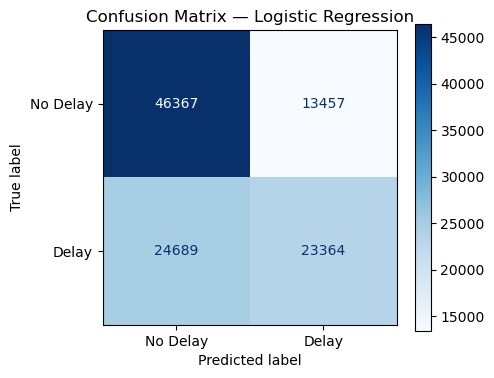

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=["No Delay", "Delay"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()


## 11. ROC Curve and Precision-Recall Curve

**ROC Curve** — plots True Positive Rate vs. False Positive Rate across all thresholds.  
AUC = 0.5 means random guessing. AUC = 1.0 means perfect separation.

**Precision-Recall Curve** — more informative when recall is low.  
The dashed horizontal line shows the baseline precision (= delay rate in test set).

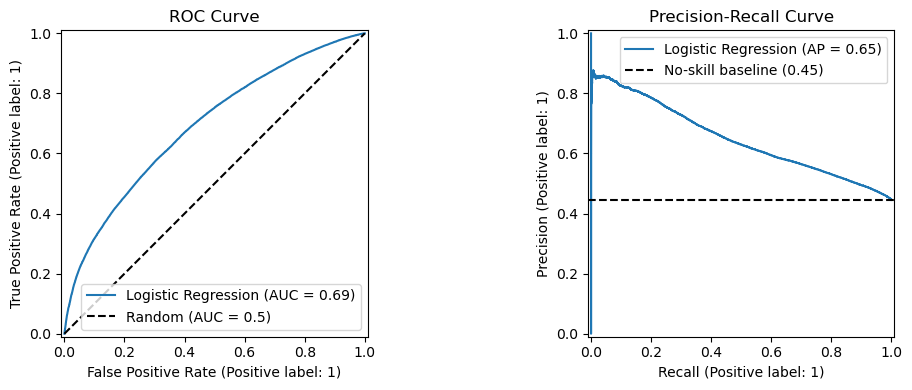

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba_lr, ax=ax1, name="Logistic Regression")
ax1.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax1.set_title("ROC Curve")
ax1.legend()

# Precision-Recall Curve
# The dashed line = baseline precision if we predicted 'Delay' for every flight
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr, ax=ax2, name="Logistic Regression")
ax2.axhline(y_test.mean(), color="k", linestyle="--",
            label=f"No-skill baseline ({y_test.mean():.2f})")
ax2.set_title("Precision-Recall Curve")
ax2.legend()

plt.tight_layout()
plt.show()


## 12. Feature Importance — LR Coefficients

In Logistic Regression, each feature has a **coefficient** that represents its contribution  
to the log-odds of a delay. Because features are standardized, coefficients are directly comparable.

- **Positive coefficient** → feature increases delay probability
- **Negative coefficient** → feature decreases delay probability
- **Larger absolute value** → stronger influence on the prediction

Top 20 most influential features:


,Feature,Coefficient
0,Airline_WN,1.378455
1,AirportTo_OME,0.900691
2,AirportFrom_ECP,-0.864737
3,AirportFrom_ORD,0.864003
4,AirportFrom_HRL,-0.852067
5,AirportTo_JAC,0.781684
6,AirportTo_LSE,-0.776932
7,AirportTo_SJU,0.775549
8,AirportFrom_LFT,-0.768144
9,AirportFrom_KOA,-0.750649


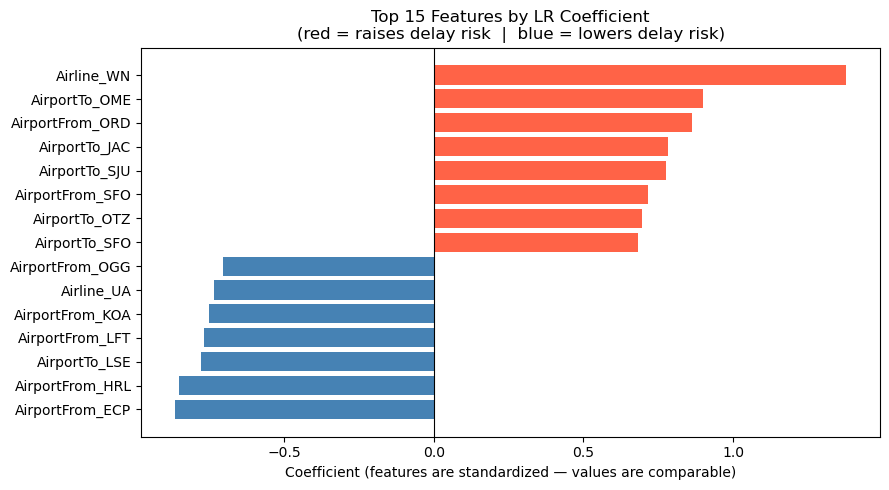

In [12]:
# Extract feature names after OHE transformation
ohe_names = (
    lr_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(CATEGORICAL)
    .tolist()
)
# Full feature name list: numeric first (as in ColumnTransformer order), then OHE
feature_names = NUMERIC + ohe_names
coefs = lr_pipeline.named_steps["classifier"].coef_[0]

coef_df = (
    pd.DataFrame({"Feature": feature_names, "Coefficient": coefs})
    .assign(AbsCoef=lambda d: d["Coefficient"].abs())
    .sort_values("AbsCoef", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 most influential features:")
display(coef_df[["Feature", "Coefficient"]].head(20))

# ── Bar chart: top 15 by absolute coefficient ────────────────────────────────
top15 = coef_df.head(15).sort_values("Coefficient")
colors = ["tomato" if c > 0 else "steelblue" for c in top15["Coefficient"]]

plt.figure(figsize=(9, 5))
plt.barh(top15["Feature"], top15["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 Features by LR Coefficient\n(red = raises delay risk  |  blue = lowers delay risk)")
plt.xlabel("Coefficient (features are standardized — values are comparable)")
plt.tight_layout()
plt.show()


## 13. Predicted Probability Distribution

Shows how confident the model is in its predictions, split by actual outcome.

- **Good model:** two distinct peaks near 0 and 1 — clear separation between classes
- **Weak model:** both distributions cluster around 0.5 — the model is uncertain

If we see heavy overlap here, it is a signal that a more powerful model  
(e.g. Random Forest) may learn better decision boundaries.

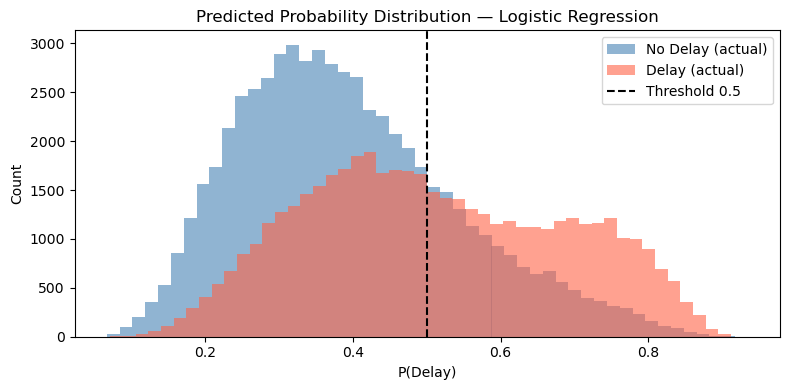

In [13]:
plt.figure(figsize=(8, 4))

# Probability distribution for flights that were NOT delayed
plt.hist(y_proba_lr[y_test == 0], bins=50, alpha=0.6,
         label="No Delay (actual)", color="steelblue")

# Probability distribution for flights that WERE delayed
plt.hist(y_proba_lr[y_test == 1], bins=50, alpha=0.6,
         label="Delay (actual)", color="tomato")

# Default classification threshold
plt.axvline(0.5, color="black", linestyle="--", label="Threshold 0.5")

plt.title("Predicted Probability Distribution — Logistic Regression")
plt.xlabel("P(Delay)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


## 14. Save Model and Metrics

- **Model** saved as `.pkl` via `joblib` — loaded by the FastAPI app and notebook 03
- **Metrics CSV** includes both Dummy and LR results — used for comparison in notebook 03

In [14]:
# ── Save trained model ───────────────────────────────────────────────────────
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "baseline_model.pkl"
joblib.dump(lr_pipeline, MODEL_PATH)
print(f"Model saved   : {MODEL_PATH}")

# ── Save metrics for notebook 03 ────────────────────────────────────────────
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Both models saved so notebook 03 can load and extend this comparison table
metrics_df = pd.DataFrame([
    {"model": "DummyClassifier",    **dummy_metrics},
    {"model": "LogisticRegression", **lr_metrics},
])
METRICS_PATH = OUTPUT_DIR / "baseline_metrics.csv"
metrics_df.to_csv(METRICS_PATH, index=False)
print(f"Metrics saved : {METRICS_PATH}")


Model saved   : ..\models\baseline_model.pkl
Metrics saved : ..\data\processed\baseline_metrics.csv


## 15. MLflow Logging

Log both models to MLflow under the same `DelayPredict` experiment as all other notebooks.  
After running this cell, start the MLflow UI with:
```
mlflow ui
```
Then open `http://localhost:5000` to compare all runs side by side.

In [ ]:
mlflow.set_tracking_uri("file:///app/notebooks/mlruns")

mlflow.set_experiment("DelayPredict")

# ── Log DummyClassifier run ──────────────────────────────────────────────────
with mlflow.start_run(run_name="DummyClassifier"):
    mlflow.log_params({
        "model"       : "DummyClassifier",
        "strategy"    : "most_frequent",
        "random_state": RANDOM_STATE,
        "train_size"  : X_train.shape[0],
        "test_size"   : X_test.shape[0],
        "features"    : ", ".join(X.columns.tolist()),
    })
    mlflow.log_metrics({
        "accuracy" : dummy_metrics["Accuracy"],
        "precision": dummy_metrics["Precision"],
        "recall"   : dummy_metrics["Recall"],
        "f1"       : dummy_metrics["F1"],
        "roc_auc"  : dummy_metrics["ROC-AUC"],
    })

# ── Log LogisticRegression run ───────────────────────────────────────────────
with mlflow.start_run(run_name="LogisticRegression"):
    lr_clf = lr_pipeline.named_steps["classifier"]
    mlflow.log_params({
        "model"       : "LogisticRegression",
        "encoding"    : "OneHotEncoder",
        "C"           : lr_clf.C,
        "max_iter"    : lr_clf.max_iter,
        "solver"      : lr_clf.solver,
        "random_state": RANDOM_STATE,
        "train_size"  : X_train.shape[0],
        "test_size"   : X_test.shape[0],
        "features"    : ", ".join(X.columns.tolist()),
    })
    mlflow.log_metrics({
        "accuracy" : lr_metrics["Accuracy"],
        "precision": lr_metrics["Precision"],
        "recall"   : lr_metrics["Recall"],
        "f1"       : lr_metrics["F1"],
        "roc_auc"  : lr_metrics["ROC-AUC"],
    })
    mlflow.sklearn.log_model(lr_pipeline, artifact_path="model")

print("MLflow runs logged — experiment: 'DelayPredict'")
print("Runs: DummyClassifier, LogisticRegression")
print("Start MLflow UI with: mlflow ui")


## 16. Summary

Final results and next steps.

In [15]:
print("BASELINE RESULTS")
print("=" * 40)
print(f"Train : {X_train.shape[0]:>7,} rows")
print(f"Test  : {X_test.shape[0]:>7,} rows")
print()
print(f"{'Metric':<12} {'Dummy':>8} {'LR':>8} {'Delta':>8}")
print("-" * 40)
for _, row in comparison_df.iterrows():
    print(f"{row['Metric']:<12} {row['Dummy']:>8.4f} {row['LR']:>8.4f} {row['Delta']:>+8.4f}")
print()
print("Features:", X.columns.tolist())
print()
print("Next: notebook 03 — Random Forest / Gradient Boosting vs. this baseline")


BASELINE RESULTS
Train : 431,506 rows
Test  : 107,877 rows

Metric          Dummy       LR    Delta
----------------------------------------
Accuracy       0.5546   0.6464  +0.0918
Precision      0.0000   0.6345  +0.6345
Recall         0.0000   0.4862  +0.4862
F1             0.0000   0.5506  +0.5506
ROC-AUC        0.5000   0.6921  +0.1921

Features: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'DepartureHour']

Next: notebook 03 — Random Forest / Gradient Boosting vs. this baseline
